
# Validating the Python/JuPedSim ORCA model against van den Berg, Guy, Lin & Manocha (2011)

This notebook checks a Python implementation of **Optimal Reciprocal
Collision Avoidance (ORCA)**, running inside **JuPedSim**'s
`CustomOperationalModel` plugin API (the same pattern as the SFM and RVO
notebooks in this repo), against the paper that introduced it:

> J. van den Berg, S. J. Guy, M. Lin, D. Manocha. *Reciprocal n-Body
> Collision Avoidance.* In: Robotics Research (ISRR 2009), Springer Tracts
> in Advanced Robotics vol. 70, pp. 3–19, 2011.
> [doi:10.1007/978-3-642-19457-3_1](https://doi.org/10.1007/978-3-642-19457-3_1)

ORCA is the successor of RVO by the same group. Instead of sampling
candidate velocities, every neighbour B induces one **half-plane** of
permitted velocities for agent A (A takes half of the smallest change that
avoids a collision within a time window τ, Eq. 6), static obstacles add
half-planes that A must respect alone (Section 5.4), and the new velocity
is the point of the intersection closest to the preferred velocity, found
with a small linear program (Eqs. 7–8). When the half-planes do not
intersect (very dense crowds) a 3-D linear program picks the "least
penetrating" velocity instead (Eq. 10), and the collision-free guarantee
is lost.

**How the paper validates ORCA** (Section 6; see `model_description.md`).
All validation is synthetic, with no real pedestrian data:

| Paper figure | Experiment | What is reported |
|---|---|---|
| Fig. 7(a) | two robots exchange positions | picture only: "they change velocities to smoothly avoid it" |
| Fig. 7(b) | five robots cross to antipodal points on a circle | picture only: "the robots smoothly spiral around each other" |
| Fig. 8 | 1,000 agents cross a circle to antipodal points | 3 snapshots: "robots smoothly move through the congestion that forms in the center" |
| Fig. 9 | 1,000 agents evacuate an office along globally planned paths | 3 snapshots, no numbers |
| Fig. 10(a) | Office: speed-up on 1–8 cores, N = 500 / 1,000 / 5,000 | numeric plot |
| Fig. 10(b) | Circle and Office: ms per frame vs. N = 500 … 5,000 on 8 cores | numeric plot; text: 8 ms (Circle) and 15.6 ms (Office) at N = 5,000 |

The guarantee behind all of this (Sections 4–5) is that agents are
**collision-free for at least τ** whenever the linear program is feasible,
and that obstacle constraints are **never** relaxed.

**Code layout** (all in `ORCA/`):

- `pyORCA.py`: the model (`ORCAModel`, `ORCAState`).
- `validation/run_circle.py`: Circle scenarios (Fig. 7a with N = 2,
  Fig. 7b with N = 5, Fig. 8 with N = 1,000).
- `validation/run_fig7b_sensitivity.py`: the five-robot deadlock sweep.
- `validation/run_office.py`: office evacuation (Fig. 9).
- `validation/run_timing_sweep.py`: Fig. 10(b) timings, one process per point.
- `validation/analysis.py`: trajectory loading and metrics.
- `validation/results/`: `.sqlite` trajectories, `.json` summaries,
  `plot_*.png`, and `paper_fig*.png` crops of the paper's figures.


In [1]:

import pathlib
import sys

# jupedsim is not pip-installed; its Python package and compiled bindings are
# made importable via PYTHONPATH (see jupedsim/build/environment). Jupyter
# kernels don't inherit that, so replicate it here. The kernel cwd is this
# notebook's folder (ORCA/), matching the pathlib.Path("validation") usage below.
_REPO = pathlib.Path.cwd().parent
_JP = _REPO / "jupedsim"
for _d in (
    _JP / "python_modules" / "jupedsim_examples",
    _JP / "build" / "stage",
):
    _p = str(_d.resolve())
    if _p not in sys.path:
        sys.path.insert(0, _p)

# sanity check
from jupedsim.internal.notebook_utils import animate, read_sqlite_file
print("jupedsim import OK")


jupedsim import OK


In [2]:

import json
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from shapely.plotting import plot_polygon

import sys
sys.path.insert(0, str(pathlib.Path("validation").resolve()))
from analysis import (
    load_trajectory, load_geometry, clearance_per_frame, wall_clearance,
    reached_target, arrival_times, trim_to_active_phase, path_metrics,
)

RESULTS = pathlib.Path("validation/results")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Same caveat as the SFM and RVO notebooks: this is JuPedSim's own internal
# replay utility ("We make no promises about the functions from this file
# w.r.t. API stability"). We use it anyway; there is no public alternative.
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

AGENT_RADIUS = 0.25


def load_run(tag):
    with open(RESULTS / f"{tag}.json") as f:
        s = json.load(f)
    df, fps = load_trajectory(RESULTS / f"{tag}.sqlite") if s.get("db_path") else (None, None)
    return s, df



### Reference values from the original paper

Every figure below also shows the paper's own result, drawn in dashed
black and labelled "paper".

**Numeric data (Fig. 10).** Both panels of Fig. 10 were
**hand-digitized**: page 17 of the PDF was rendered at 300 dpi
(`pdftoppm -r 300`), the figure was cropped, and each marker's pixel
centre was read against the printed gridlines (Fig. 10b: 0–18 ms in steps
of 2 ms, about 16 px per ms; Fig. 10a: speed-up 0–6, about 51 px per unit).
The published figure is a low-resolution JPEG, so the reading is good to
about **±0.2 ms** (Fig. 10b) and **±0.05** in speed-up (Fig. 10a). As a
check, the digitized N = 5,000 values (15.6 and 8.0 ms) match the numbers
stated in the text (15.6 ms and 8 ms).

**Claims stated in words**, turned into reference values:

- *Collision-free* (Sections 4–5: guaranteed whenever the 2-D linear
  program is feasible; obstacle constraints are never relaxed): minimum
  agent–agent clearance 0 m and minimum agent–wall clearance 0 m. The paper
  itself says the agent–agent guarantee is lost in "densely packed
  conditions" (Section 5.3), so in the congested scenarios we also report
  how often the 3-D fallback was active.
- *All robots reach their goals*: Fig. 7 shows every robot arriving. For
  Fig. 8 the paper only says that the robots "move through the congestion"
  to their antipodal positions; we read that as everyone getting there.
  Reference value: 100 % arrival.

**Pictures** (Figs. 7, 8 and 9) were cropped from the same 300-dpi
renders into `validation/results/paper_fig*.png` and are shown next to our
own plots.


In [3]:

# Hand-digitized from Fig. 10 of the paper (see markdown above for method).
PAPER_FIG10B = {  # "Running Time vs. Num. Agents (8 Cores)", milliseconds per frame
    "n": [500, 1000, 2000, 3000, 4000, 5000],
    "office_ms": [1.2, 2.9, 5.8, 9.4, 12.4, 15.6],
    "circle_ms": [1.0, 1.8, 3.3, 4.9, 6.4, 8.0],
}
PAPER_TEXT_N5000_MS = {"circle": 8.0, "office": 15.6}  # Section 6, text
PAPER_FIG10A = {  # "Performance Scaling - Office Demo", speed-up vs. cores
    "cores": [1, 2, 3, 4, 5, 6, 7, 8],
    500: [1.0, 1.72, 2.24, 2.86, 3.36, 3.72, 4.10, 4.26],
    1000: [1.0, 1.75, 2.50, 3.00, 3.63, 4.20, 4.42, 4.60],
    5000: [1.0, 1.84, 2.35, 3.27, 3.88, 4.42, 5.02, 5.40],
}
PAPER_MIN_CLEARANCE = 0.0   # collision-free (guarantee of Sections 4-5)
PAPER_ARRIVAL = 1.0         # every robot reaches its goal (Figs. 7, 8)
PAPER_FIG7A_IMG = RESULTS / "paper_fig7a_two_robots.png"
PAPER_FIG7B_IMG = RESULTS / "paper_fig7b_five_robots.png"
PAPER_FIG8_IMG = RESULTS / "paper_fig8_circle1000.png"
PAPER_FIG9_IMG = RESULTS / "paper_fig9_office.png"
PAPER_FIG10_IMG = RESULTS / "paper_fig10_performance.png"
PAPER_STYLE = dict(color="black", ls="--", alpha=0.7)



## Implementation notes: what the model does, and real problems found

`pyORCA.py` follows the paper step by step (see the class docstring):

- **Agent half-planes (Eqs. 5–6).** The optimization velocity is the
  current velocity (the paper's recommended choice, Section 5.2); u is the
  vector from the relative velocity to the closest point on the boundary of
  the truncated velocity obstacle VO^τ, and A's half-plane passes through
  v_A + u/2. The geometry (cut-off circle vs. the two legs of the cone) is
  a direct port of the authors' own reference code, the RVO2 library,
  because the paper gives the construction but not an algorithm for it.
- **Obstacle half-planes (Section 5.4).** Optimization velocity 0, so the
  delimiting line is the tangent to VO^τ_obst at its point closest to the
  origin. For a wall segment at distance d this is simply
  v · ĉ ≤ (d − r)/τ_obst, with ĉ the direction of the segment's closest
  point. We use the paper's suggestion of a smaller obstacle horizon:
  τ = 2 s for agents (the value of the paper's Figs. 1, 4 and 5),
  τ_obst = 0.5 s for walls.
- **Linear programs (Eqs. 7–8 and 10).** The randomized incremental 2-D LP
  the paper cites, and the 3-D "least penetration" LP of Section 5.3 with
  obstacle half-planes kept hard. Both are ports of RVO2's
  `linearProgram1/2/3`, with the inner loops vectorized in numpy. We
  checked them against a brute-force grid search on 400 random sets of
  half-planes (2-D LP: optimum matched in every case where the grid found
  a feasible point; 3-D LP: the max-penetration value matched in every
  infeasible case).
- **Neighbours.** Every agent within (v_max,A + v_max,B)·τ = 6 m, the
  paper's own cut-off (Section 5.1). No "k nearest" cap (RVO2 has one; the
  paper does not).

Agents: radius 0.25 m, preferred speed = maximum speed = 1.5 m/s in every
scenario (the paper does not give robot sizes or speeds).

**Problems found while running it:**

1. **Agents flip back and forth across their final waypoint.** JuPedSim
   keeps pointing an agent at its last waypoint after it arrives, so a
   pure "v_pref = v_max · direction" agent overshoots and reverses every
   step at full speed. We checked this with a one-agent run: the position
   alternated between 1.0 m and 1.1 m forever around a target at 1.03 m.
   That matters much more for ORCA than for a force model, because the
   neighbours read the *velocity*, and reciprocate against a fake
   ±1.5 m/s. The step API does not expose the distance to the target, so
   `pyORCA.py` detects the overshoot (the direction to the target reverses
   between two steps) and sets v_pref = 0 from then on (`stop_at_goal`).
   RVO2's examples do the equivalent by shrinking v_pref near the goal.
2. **That overshoot fix must be off in the office.** A sharp corner on a
   navigation-mesh route also reverses the direction to the next target,
   which would freeze evacuees in doorways, so the office runs use
   `stop_at_goal=False` (agents are removed at the exit anyway).
3. **The exactly symmetric five-robot circle deadlocks** in most settings.
   This is analysed in Section 2. The authors' RVO2 example code adds
   ≤ 1e-4 m/s of random noise to every preferred velocity "to avoid
   deadlocks due to perfect symmetry". We added the same option
   (`ORCAModel(pref_noise=1e-4)`, used in every run below except where a
   sweep sets it to 0), but found that
   it does **not** break this deadlock in most settings.
4. **Overlapping pairs.** Eq. (5) has no meaning once two disks already
   overlap, and the paper does not cover it. As RVO2 does, we then use the
   half-plane that separates the pair within one time step. This is the
   only use of `dt` inside the model.
5. As in the RVO notebook, obstacles are built as a `shapely.Polygon` with
   holes and passed as `geometry=`, because `excluded_areas=` is silently
   ignored by this JuPedSim build.

### Choosing `dt`

ORCA is velocity-based, so large steps are stable, but its guarantee is
for motion held for τ. A step recomputed every `dt` in a dense jam lets
agents that are in the 3-D fallback drift into each other by up to about
v·dt. We ran the two-robot swap and a 250-agent circle (the congested case)
at progressively smaller `dt`:


In [4]:

rows = []
for dt in ["0.2", "0.1", "0.05", "0.025", "0.0125"]:
    s2 = json.load(open(RESULTS / f"dtscan_n2_dt{dt}.json"))
    row = {"dt [s]": float(dt), "N=2 min clearance [m]": s2["min_clearance_running"]}
    p = RESULTS / f"dtscan_n250_dt{dt}.json"
    if p.exists():
        s, df = load_run(f"dtscan_n250_dt{dt}")
        tg = {int(k): v for k, v in s["targets"].items()}
        arr = arrival_times(df, tg, 0.3)
        c = clearance_per_frame(df, AGENT_RADIUS)
        row.update({
            "N=250 min clearance [m]": s["min_clearance_running"],
            "N=250 5th pct of per-frame min [m]": np.percentile(c["min_clearance"], 5),
            "N=250 arrived": f"{arr.notna().sum()}/{s['n']}",
            "N=250 median arrival [s]": arr.median(),
            "N=250 last arrival [s]": arr.max(),
            "ms/step": s["mean_step_time_ms"],
        })
    rows.append(row)
dt_df = pd.DataFrame(rows)
dt_df.round(4)


,dt [s],N=2 min clearance [m],N=250 min clearance [m],N=250 5th pct of per-frame min [m],N=250 arrived,N=250 median arrival [s],N=250 last arrival [s],ms/step
0,0.2000,0.0443,-0.4470,-0.2398,250/250,57.2,72.2,44.6444
1,0.1000,0.0006,-0.2926,-0.0176,250/250,92.7,131.6,53.3447
2,0.0500,0.0017,-0.1006,-0.0028,250/250,94.0,118.8,56.5100
3,0.0250,0.0005,-0.0245,-0.0007,250/250,97.9,122.2,56.8458
4,0.0125,0.0001,-0.0027,-0.0002,250/250,87.6,120.0,52.9534



**Chosen: `dt = 0.025` s.** The two-robot swap is collision-free at every
`dt` tried. In the 250-agent circle the deepest overlap roughly halves or
better with each halving of `dt`: −0.45, −0.29, −0.10, −0.02 m from 0.2 to
0.025 s, so it is a discretization effect, not a property of ORCA itself.
(0.0125 s: −0.003 m.) The macroscopic result converges too: `dt = 0.2` s lets agents squeeze
through each other and finish in about 70 s, while every `dt ≤ 0.1` s run
takes about 120 s, with median arrival times within a few seconds of each
other. At 0.025 s the worst overlap is 2 cm (4 % of a body diameter) and
the typical per-frame minimum is about −1 mm. Halving again (0.0125 s)
brings the worst overlap down to −3 mm, but doubles the cost of every run
without changing the arrival times, so we stop at 0.025 s. The RVO
notebook chose the same `dt`.


In [5]:

def disk_trace(ax, df, colors, n_samples=11, t_end=None, radius=AGENT_RADIUS):
    '''Paper's Fig. 7 style: each robot drawn as a disk at n_samples evenly
    spaced times, light at the start and darkening as time progresses.'''
    t_end = df["t"].max() if t_end is None else t_end
    times = np.linspace(0.0, t_end, n_samples)
    for k, (agent_id, g) in enumerate(df.groupby("id")):
        g = g.sort_values("t")
        base = np.array(plt.matplotlib.colors.to_rgb(colors[k % len(colors)]))
        for i, t in enumerate(times):
            row = g.iloc[np.argmin(np.abs(g["t"].to_numpy() - t))]
            f = 0.25 + 0.75 * i / (n_samples - 1)
            c = (1 - f) * np.ones(3) + f * base
            ax.add_patch(Circle((row["pos_x"], row["pos_y"]), radius, fc=c, ec="black",
                                lw=0.6, zorder=i + 10 * (k % 2)))
    ax.set_aspect("equal")
    ax.autoscale_view()


def show_img(ax, path, title):
    ax.imshow(plt.imread(path))
    ax.set_title(title, fontsize=9)
    ax.axis("off")



## 1. Two robots exchange positions (Fig. 7a)

**Paper's setup.** Two robots start facing each other and swap places.
"When the robots notice that a collision is imminent (i.e. it will happen
within τ time), they change velocities to smoothly avoid it." Only a
picture is given: from its disk trace, the two start about six diameters
apart and pass each other with a small, smooth sideways deviation.

**Our setup** (`run_circle.py --n 2 --circle-radius 1.5`): two agents
3.0 m apart (six diameters, as measured from Fig. 7a), exactly head-on,
starting at rest, τ = 2 s. Each has its own target (the other's start).


In [6]:

s7a, df7a = load_run("fig7a_two_robots")
tg7a = {int(k): v for k, v in s7a["targets"].items()}
arr7a = arrival_times(df7a, tg7a, 0.15)
act7a = trim_to_active_phase(df7a, tg7a, 0.15, buffer=0.0)
pm7a = path_metrics(act7a, resample_dt=0.1)
c7a = clearance_per_frame(df7a, AGENT_RADIUS)
free_walk = (2 * s7a["circle_radius"] - 0.15) / s7a["speed"]  # to within the 0.15 m arrival tolerance
fig7a_table = pd.DataFrame({
    "arrival time [s]": arr7a,
    "delay vs. straight walk [s]": arr7a - free_walk,
    "max sideways deviation [m]": act7a.groupby("id")["pos_y"].apply(lambda y: y.abs().max()),
    "path length / straight": pm7a["tortuosity"],
    "largest heading change per 0.1 s [deg]": pm7a["max_turn_deg"],
})
print(f"minimum clearance: {c7a['min_clearance'].min():+.4f} m (paper: >= {PAPER_MIN_CLEARANCE})")
print(f"arrived: {arr7a.notna().mean():.0%} (paper: {PAPER_ARRIVAL:.0%})")
fig7a_table.round(3)


minimum clearance: +0.0005 m (paper: >= 0.0)
arrived: 100% (paper: 100%)


,arrival time [s],delay vs. straight walk [s],max sideways deviation [m],path length / straight,largest heading change per 0.1 s [deg]
1,2.05,0.15,0.251,1.015,15.208
2,2.05,0.15,0.251,1.015,15.208


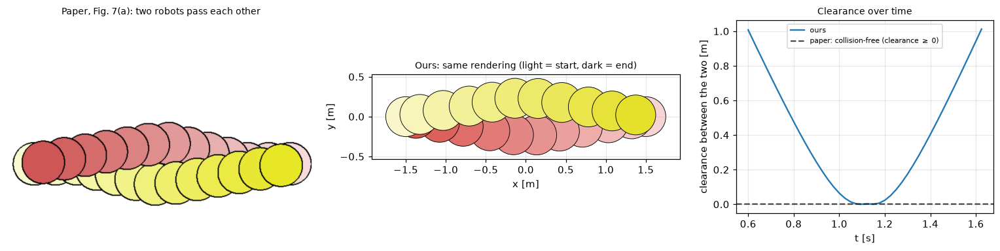

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1.2, 1.2, 1]})
show_img(axes[0], PAPER_FIG7A_IMG, "Paper, Fig. 7(a): two robots pass each other")
disk_trace(axes[1], act7a, ["#d9534f", "#e5e02a"], n_samples=11)
axes[1].set_title("Ours: same rendering (light = start, dark = end)", fontsize=9)
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
ax = axes[2]
ax.plot(c7a["t"], c7a["min_clearance"], color="tab:blue", label="ours")
ax.axhline(PAPER_MIN_CLEARANCE, lw=1.5, label="paper: collision-free (clearance $\\geq$ 0)", **PAPER_STYLE)
ax.set_xlabel("t [s]"); ax.set_ylabel("clearance between the two [m]")
ax.set_title("Clearance over time", fontsize=9)
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig7a_two_robots.png", dpi=130)
plt.show()


In [8]:

traj_7a, area_7a = read_sqlite_file(str(RESULTS / "fig7a_two_robots.sqlite"))
animate(traj_7a, area_7a, every_nth_frame=2, radius=AGENT_RADIUS, title_note="Fig. 7(a): two robots")



**Verdict: reproduced.** The two agents never touch (minimum clearance
+0.5 mm, so the paper's collision-free claim holds), both arrive, and the
avoidance is a single sideways bulge of 0.25 m (half a body diameter)
each, the reciprocal half-and-half split of Eq. (6). It looks like
Fig. 7(a). The largest heading change is 15° per 0.1 s, with no
reversals, and the pass costs only 0.15 s over a straight walk, because
ORCA starts sidestepping as soon as the collision falls within τ = 2 s,
i.e. from the very first step here.

One difference: **our pair passes on their left, the paper's on their
right.** An exactly head-on pair is a tie in ORCA's "which leg of the
cone" choice, so the side is decided by rounding and by the 1e-4 m/s
noise, not by the model's rules. With the same setup, seeds 1, 4 and 5
(and no noise at all) passed on the left, and seeds 2 and 3 on the right.
We kept seed 1, the seed used everywhere else, rather than picking the
one that matches the picture. Either way the two agents break the tie
the same way, so they never mirror each other into a stand-off.



## 2. Five robots cross to antipodal points (Fig. 7b)

**Paper's setup.** Five robots on a circle, each heading for the
antipodal point: "the robots smoothly spiral around each other to avoid
collisions". We measured the start positions from the figure: the five
start angles are evenly spaced to within about 0.5° (gaps 71.4°–72.4°),
and the circle radius is about 4.5 robot radii. So the paper's setup is
exactly symmetric, as far as the figure can show.

**Our setup** (`run_circle.py --n 5 --circle-radius 1.1`): five agents,
evenly spaced on a circle of radius 1.1 m (4.4 radii), τ = 2 s.
Our headline run starts the agents **already walking** at 1.5 m/s
towards their goals. That choice is explained, and its alternatives
measured, just below: started **from rest**, the same setup deadlocks.


In [9]:

s7b, df7b = load_run("fig7b_five_robots")
s7r, df7r = load_run("fig7b_five_robots_from_rest")
rows = []
for label, s, df in [("already walking (headline)", s7b, df7b), ("from rest", s7r, df7r)]:
    tg = {int(k): v for k, v in s["targets"].items()}
    arr = arrival_times(df, tg, 0.15)
    act = trim_to_active_phase(df, tg, 0.15, buffer=0.0)
    pm = path_metrics(act, resample_dt=0.1)
    c = clearance_per_frame(df, AGENT_RADIUS)
    last = df[df["frame"] == df["frame"].max()]
    rows.append({
        "start": label,
        "arrived": f"{arr.notna().sum()}/5",
        "last arrival [s]": arr.max(),
        "delay vs. straight walk [s]": f"{arr.min() - (2 * s['circle_radius'] - 0.15) / s['speed']:.2f} to {arr.max() - (2 * s['circle_radius'] - 0.15) / s['speed']:.2f}" if arr.notna().all() else "-",
        "min clearance [m]": c["min_clearance"].min(),
        "max heading change per 0.1 s [deg]": pm["max_turn_deg"].max(),
        "reversals": int(pm["reversals"].sum()),
        "final dist. from centre [m]": np.hypot(last["pos_x"], last["pos_y"]).mean(),
    })
fig7b_table = pd.DataFrame(rows)
fig7b_table.round(3)


,start,arrived,last arrival [s],delay vs. straight walk [s],min clearance [m],max heading change per 0.1 s [deg],reversals,final dist. from centre [m]
0,already walking (headline),5/5,1.875,0.03 to 0.51,0.000,51.633,0,1.129
1,from rest,0/5,NaN,-,0.014,0.000,0,0.437


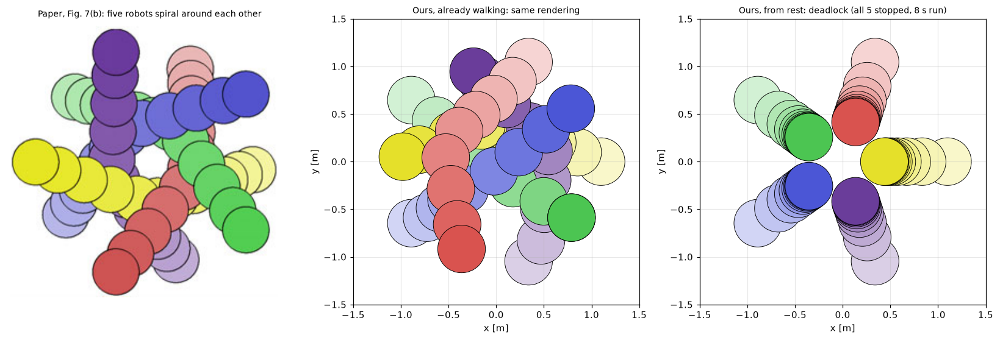

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
show_img(axes[0], PAPER_FIG7B_IMG, "Paper, Fig. 7(b): five robots spiral around each other")
# Colours matched to the paper by start angle: yellow at 0 deg, then red,
# green, blue, purple counter-clockwise (read off Fig. 7b).
paper_colors = ["#e5e02a", "#d9534f", "#4cc552", "#4b56d6", "#6a3d9a"]
tg7b = {int(k): v for k, v in s7b["targets"].items()}
disk_trace(axes[1], trim_to_active_phase(df7b, tg7b, 0.15, buffer=0.0), paper_colors, n_samples=9)
axes[1].set_title("Ours, already walking: same rendering", fontsize=9)
disk_trace(axes[2], df7r, paper_colors, n_samples=9)
axes[2].set_title(f"Ours, from rest: deadlock (all 5 stopped, {s7r['sim_time_completed']:.0f} s run)", fontsize=9)
for ax in axes[1:]:
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig7b_five_robots.png", dpi=130)
plt.show()



**Why "from rest" deadlocks.** By symmetry, every pair of neighbours'
relative velocity stays exactly parallel to their relative position. The
ORCA construction then always takes the cut-off-circle branch of the
velocity obstacle, whose half-plane normal is the line between the two
centres, so it is mirror-symmetric. Each agent's optimum sits at the
vertex where its two neighbours' half-planes meet, on the radial axis, and
the agents approach the centre ever more slowly: we measured the speed
decaying in proportion to the distance from the centre (v ≈ 0.44·|p|,
just under 1/τ = 0.5 s⁻¹), until they stand touching each other. A
1e-4 m/s perturbation of v_pref cannot move an optimum that sits at a
vertex, which is why RVO2's noise does not help here. When the agents
start already walking, the relative velocity is large enough that
the construction takes the *legs* branch instead. There the tie
"which leg?" is resolved identically by every agent (the right leg),
which keeps the 5-fold rotational symmetry but breaks the mirror symmetry,
and that is exactly the roundabout of Fig. 7(b).

The paper states none of τ, the robots' speed or their start velocity for
Fig. 7, so we swept them (`run_fig7b_sensitivity.py`, each run its own
process, `dt = 0.025` s, run length = straight-walk time + 12 s):


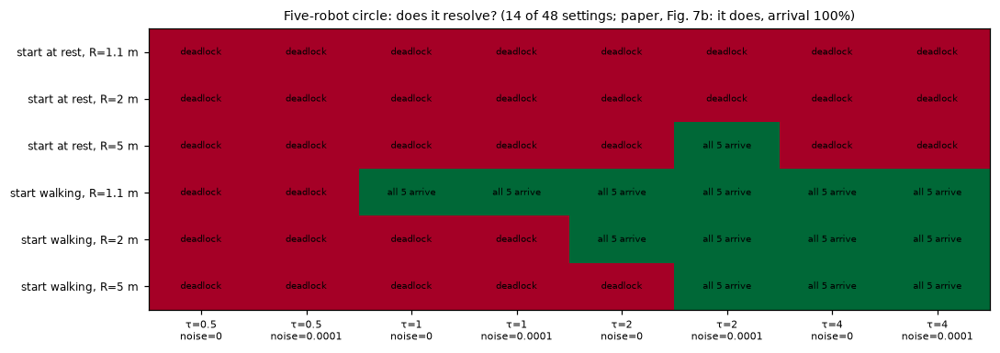

Minimum clearance over all 48 runs: -1.11e-16 m


In [11]:

sens = pd.DataFrame(json.load(open(RESULTS / "fig7b_sensitivity.json"))["rows"])
sens["resolved"] = sens["n_arrived"] == 5
pivot = sens.pivot_table(index=["initial_speed", "circle_radius"], columns=["tau", "pref_noise"],
                         values="resolved", aggfunc="first")
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.imshow(pivot.to_numpy().astype(float), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(pivot.shape[1]), [f"τ={t:g}\nnoise={n:g}" for t, n in pivot.columns], fontsize=7)
ax.set_yticks(range(pivot.shape[0]), [f"start {'walking' if v else 'at rest'}, R={r:g} m" for v, r in pivot.index], fontsize=8)
for (i, j), val in np.ndenumerate(pivot.to_numpy()):
    ax.text(j, i, "all 5 arrive" if val else "deadlock", ha="center", va="center", fontsize=6.5)
ax.grid(False)
ax.set_title(f"Five-robot circle: does it resolve? ({int(sens['resolved'].sum())} of {len(sens)} settings; "
             f"paper, Fig. 7b: it does, arrival {PAPER_ARRIVAL:.0%})", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig7b_sensitivity.png", dpi=130)
plt.show()
print("Minimum clearance over all 48 runs:", f"{sens['min_clearance'].min():+.2e} m")


In [12]:

traj_7b, area_7b = read_sqlite_file(str(RESULTS / "fig7b_five_robots.sqlite"))
animate(traj_7b, area_7b, every_nth_frame=2, radius=AGENT_RADIUS, title_note="Fig. 7(b): five robots, already walking")


In [13]:

traj_7r, area_7r = read_sqlite_file(str(RESULTS / "fig7b_five_robots_from_rest.sqlite"))
animate(traj_7r, area_7r, every_nth_frame=8, radius=AGENT_RADIUS, title_note="Fig. 7(b) setup, from rest: deadlock")



**Verdict: partly reproduced.** With the agents already walking, our five
robots form the same roundabout as Fig. 7(b). Every robot passes the
centre on the same side, around a small empty hole, and reaches its goal
0.03–0.51 s later than a straight walk, with no collision (minimum clearance
0.0 m, i.e. touching but not overlapping) and no heading reversals. The
rendering above matches the paper's picture closely, down to where each
colour starts and ends and which way the roundabout turns. The paths are
piecewise straight rather than curved: ORCA is velocity-based with no
inertia, so each robot changes heading in one short burst (at most 27°
per 0.1 s) while passing. The one larger turn, 52°, is a robot in its first
0.2 s, when ORCA replaces the start velocity we imposed. But this outcome is **not robust**:
in the same exactly symmetric setup, ORCA deadlocks in 34 of the 48
settings we tried. Starting from rest, 23 of 24 settings deadlock; the
only exception (τ = 2 s, R = 5 m, with noise) resolves only at the very
end of its run. Starting already walking, 13 of 24 resolve: every setting
with τ = 4 s, but never with τ = 0.5 s. None of the 48 runs collide (the
deadlocked robots stand touching, clearance ≥ 0), so the paper's safety
claim holds throughout. Its "smoothly spiral" claim is what depends on
details the paper does not report. RVO2's symmetry-breaking noise changes
the outcome in only 2 of the 48 settings (both τ = 2 s, R = 5 m), and only
after a long stall.



## 3. 1,000 agents on a circle (Fig. 8)

**Paper's setup.** 1,000 agents on a large circle move through the centre
to their antipodal points. Three snapshots show the start (a ring several
agents thick, coloured by position on the ring), a congested disk filling
the centre, and the agents fanning out on the other side: "Robots smoothly
move through the congestion that forms in the center." No numbers are
given. The circle's size, the agents' size and speed, and τ are not
reported.

**Our setup** (`run_circle.py --n 1000 --rows 4 --spacing 0.8`):
1,000 agents on 4 concentric rings (250 per ring, 0.8 m apart along and
across the ring; inner radius 31.8 m), from rest, τ = 2 s,
`dt = 0.025` s, trajectory recorded every 0.2 s. The run stops when every
agent has arrived (or at 300 s). A ring several agents thick is what
Fig. 8's first panel shows.


In [14]:

s8, df8 = load_run("fig8_circle_n1000")
tg8 = {int(k): v for k, v in s8["targets"].items()}
arr8 = arrival_times(df8, tg8, 0.3)
c8 = clearance_per_frame(df8, AGENT_RADIUS)
free8 = 2 * np.array([np.hypot(*v) for v in tg8.values()]) / s8["speed"]
frac3d8 = np.array(s8["fraction_3d_lp_per_step"])
t_steps8 = (np.arange(len(frac3d8)) + 1) * s8["dt"]
deep8 = clearance_per_frame(df8, AGENT_RADIUS - 0.005)  # pairs overlapping by more than 1 cm
print(f"Simulated {s8['sim_time_completed']:.1f} s in {s8['n_steps_completed']} steps; crashed: {s8['crashed']}")
fin8 = reached_target(df8, tg8, 0.3)
print(f"Reached own target (first time within 0.3 m): {arr8.notna().mean():.1%} ({arr8.notna().sum()}/{len(tg8)}), "
      f"paper: {PAPER_ARRIVAL:.0%}; still within 0.3 m of it at the end: {fin8.sum()}/{len(tg8)}")
print(f"Arrival time: median {arr8.median():.1f} s, last {arr8.max():.1f} s "
      f"(straight walk: {free8.min():.1f}-{free8.max():.1f} s)")
print(f"Min clearance over the run: {c8['min_clearance'].min():+.3f} m (paper: >= {PAPER_MIN_CLEARANCE}); "
      f"frames with any overlap: {np.mean(c8['n_overlapping_pairs'] > 0):.0%}, "
      f"with an overlap deeper than 1 cm: {np.mean(deep8['n_overlapping_pairs'] > 0):.0%}")
print(f"Agents in the 3-D fallback (LP infeasible): up to {frac3d8.max():.0%} per step, "
      f"{frac3d8.mean():.1%} on average")


Simulated 300.0 s in 12000 steps; crashed: None
Reached own target (first time within 0.3 m): 99.8% (998/1000), paper: 100%; still within 0.3 m of it at the end: 608/1000
Arrival time: median 142.6 s, last 257.4 s (straight walk: 42.4-45.6 s)
Min clearance over the run: -0.034 m (paper: >= 0.0); frames with any overlap: 70%, with an overlap deeper than 1 cm: 1%
Agents in the 3-D fallback (LP infeasible): up to 92% per step, 25.6% on average


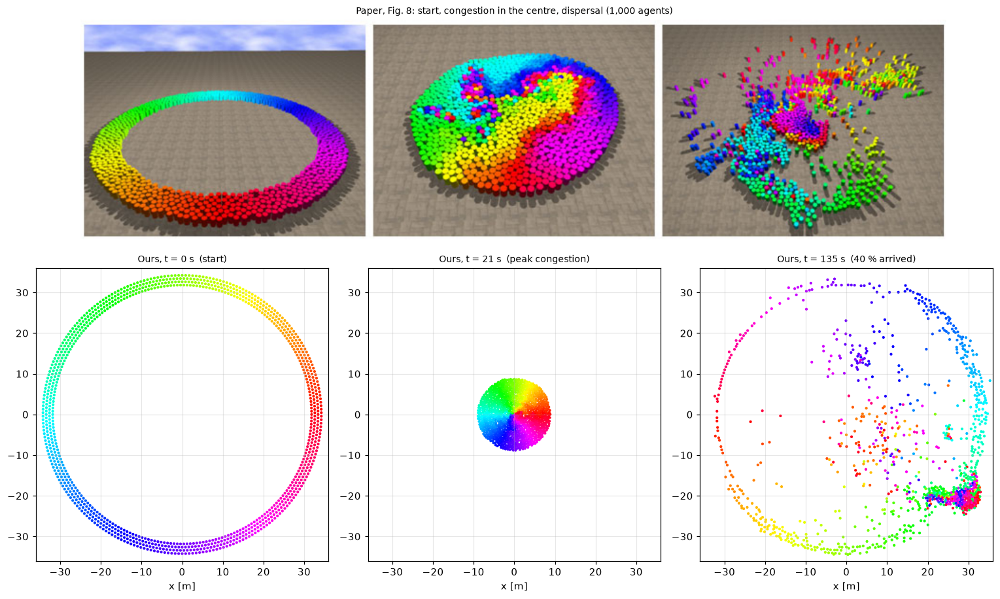

In [15]:

# Snapshot times chosen by rule, to match the three phases of Fig. 8:
# start; peak congestion (most agents within 8 m of the centre); and the
# first time 40 % of agents have arrived (fanning out on the far side).
df8["r"] = np.hypot(df8["pos_x"], df8["pos_y"])
near = df8[df8["r"] < 8.0].groupby("t").size()
t_cong = near.idxmax()
t_disp = float(np.sort(arr8.dropna())[int(0.4 * len(tg8))])
snap_t = [0.0, t_cong, t_disp]
start = df8[df8["frame"] == df8["frame"].min()].set_index("id")
hue = (np.arctan2(start["pos_y"], start["pos_x"]) % (2 * np.pi)) / (2 * np.pi)

fig = plt.figure(figsize=(14, 8.5))
gs = fig.add_gridspec(2, 3, height_ratios=[0.8, 1.2])
ax_p = fig.add_subplot(gs[0, :])
show_img(ax_p, PAPER_FIG8_IMG, "Paper, Fig. 8: start, congestion in the centre, dispersal (1,000 agents)")
for k, t in enumerate(snap_t):
    ax = fig.add_subplot(gs[1, k])
    fr = df8.loc[(df8["t"] - t).abs().idxmin(), "frame"]
    g = df8[df8["frame"] == fr]
    ax.scatter(g["pos_x"], g["pos_y"], c=hue.reindex(g["id"]).to_numpy(), cmap="hsv", s=3, vmin=0, vmax=1)
    ax.set_aspect("equal"); ax.set_xlim(-36, 36); ax.set_ylim(-36, 36)
    ax.set_title(f"Ours, t = {t:.0f} s" + ["  (start)", "  (peak congestion)", "  (40 % arrived)"][k], fontsize=9)
    ax.set_xlabel("x [m]")
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig8_snapshots.png", dpi=130)
plt.show()


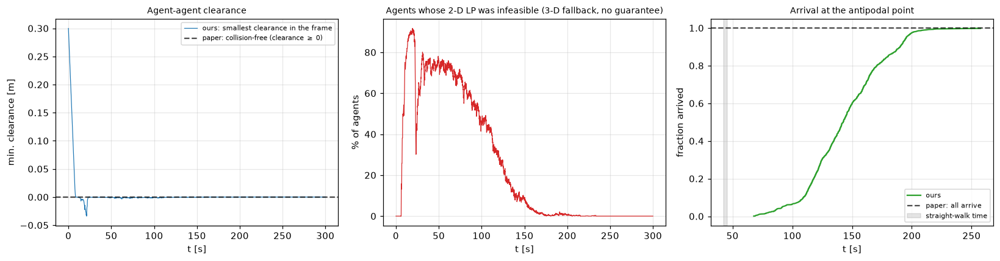

In [16]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax = axes[0]
ax.plot(c8["t"], c8["min_clearance"], lw=0.8, color="tab:blue", label="ours: smallest clearance in the frame")
ax.axhline(PAPER_MIN_CLEARANCE, lw=1.5, label="paper: collision-free (clearance $\\geq$ 0)", **PAPER_STYLE)
ax.set_xlabel("t [s]"); ax.set_ylabel("min. clearance [m]"); ax.legend(fontsize=7)
ax.set_title("Agent-agent clearance", fontsize=9)
ax = axes[1]
ax.plot(t_steps8, 100 * frac3d8, lw=0.8, color="tab:red")
ax.set_xlabel("t [s]"); ax.set_ylabel("% of agents")
ax.set_title("Agents whose 2-D LP was infeasible (3-D fallback, no guarantee)", fontsize=9)
ax = axes[2]
ts = np.sort(arr8.dropna())
ax.plot(ts, np.arange(1, len(ts) + 1) / len(tg8), color="tab:green", label="ours")
ax.axhline(PAPER_ARRIVAL, lw=1.5, label="paper: all arrive", **PAPER_STYLE)
ax.axvspan(free8.min(), free8.max(), color="gray", alpha=0.2, label="straight-walk time")
ax.set_xlabel("t [s]"); ax.set_ylabel("fraction arrived"); ax.legend(fontsize=7)
ax.set_title("Arrival at the antipodal point", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig8_metrics.png", dpi=130)
plt.show()


In [17]:

# Agents that never reached their target: what is sitting on it at the end?
last8 = df8[df8["frame"] == df8["frame"].max()].set_index("id")
P8 = last8[["pos_x", "pos_y"]].to_numpy()
for i in [i for i in tg8 if np.isnan(arr8.get(i, np.nan))]:
    tx, ty = tg8[i]
    d_t = np.hypot(P8[:, 0] - tx, P8[:, 1] - ty)
    j = int(last8.index[np.argmin(d_t)])
    moved = df8[(df8["id"] == i) & (df8["t"] >= df8["t"].max() - 60)][["pos_x", "pos_y"]]
    print(f"agent {i}: ends {np.hypot(last8.loc[i, 'pos_x'] - tx, last8.loc[i, 'pos_y'] - ty):.2f} m from its target, "
          f"moved {np.hypot(*(moved.iloc[-1] - moved.iloc[0])):.2f} m in the last 60 s; its target is occupied by "
          f"agent {j} ({d_t.min():.2f} m from it), which {'had already arrived at its own target' if not np.isnan(arr8.get(j, np.nan)) else 'had not arrived'}")


agent 329: ends 3.99 m from its target, moved 0.02 m in the last 60 s; its target is occupied by agent 79 (0.18 m from it), which had already arrived at its own target
agent 908: ends 0.32 m from its target, moved 0.00 m in the last 60 s; its target is occupied by agent 658 (0.18 m from it), which had already arrived at its own target


In [18]:

pm8 = path_metrics(trim_to_active_phase(df8, tg8, 0.3, buffer=0.0), resample_dt=0.4)
print(f"Path length / straight line: median {pm8['tortuosity'].median():.2f}, 95th pct {pm8['tortuosity'].quantile(0.95):.2f}")
# Heading reversals (>90 deg between consecutive 0.4 s steps), counted only
# where the agent moves at least `floor` m/s in BOTH steps: slow jostling in
# a jam and real walking reversals are different things.
act8 = trim_to_active_phase(df8, tg8, 0.3, buffer=0.0)
rev = {f: 0 for f in (0.05, 0.3, 0.6)}
rev_r = []
for aid, g in act8.groupby("id"):
    tt, pp = g["t"].to_numpy(), g[["pos_x", "pos_y"]].to_numpy()
    tgrid = np.arange(tt[0], tt[-1], 0.4)
    if len(tgrid) < 3:
        continue
    rp = np.stack([np.interp(tgrid, tt, pp[:, 0]), np.interp(tgrid, tt, pp[:, 1])], 1)
    v = np.diff(rp, axis=0) / 0.4
    sp = np.linalg.norm(v, axis=1)
    h = np.arctan2(v[:, 1], v[:, 0])
    turn = np.abs(np.degrees((np.diff(h) + np.pi) % (2 * np.pi) - np.pi))
    slow = np.minimum(sp[1:], sp[:-1])
    for f in rev:
        rev[f] += int(((turn > 90) & (slow >= f)).any())
    m = (turn > 90) & (slow >= 0.05)
    rev_r += list(np.hypot(rp[1:-1][m, 0], rp[1:-1][m, 1]))
for f, k in rev.items():
    print(f"Agents with at least one heading reversal while moving >= {f} m/s: {k} of {len(tg8)}")
print(f"Where the reversals happen: median {np.median(rev_r):.1f} m from the centre")


Path length / straight line: median 1.34, 95th pct 2.02
Agents with at least one heading reversal while moving >= 0.05 m/s: 572 of 1000
Agents with at least one heading reversal while moving >= 0.3 m/s: 76 of 1000
Agents with at least one heading reversal while moving >= 0.6 m/s: 7 of 1000
Where the reversals happen: median 8.6 m from the centre


In [19]:

traj_8, area_8 = read_sqlite_file(str(RESULTS / "fig8_circle_n1000.sqlite"))
n_frames = traj_8.data["frame"].nunique()
animate(traj_8, area_8, every_nth_frame=max(1, n_frames // 12), radius=AGENT_RADIUS,
        title_note="Fig. 8: 1,000 agents, circle")



**Verdict: partly reproduced.** The part of the paper's claim that can be
checked holds. A dense congestion forms in the centre, and 998 of the
1,000 agents get through it to their own antipodal point (99.8 %, paper:
all). The two that do not are not stuck in the congestion. They stand
motionless next to their target, which is occupied by an agent that had
already arrived at its own spot and was then pushed 0.18 m off it by
later arrivals (printed above). That is a side effect of our
arrive-and-stop extension (an arrived agent has v_pref = 0 and never
walks back), not of ORCA. It is also why only 608 agents are still within
0.3 m of their target at the end.

**Collisions:** none until the crowd compresses in the centre (t ≈ 20 s).
After that there are shallow overlaps, worst −3.4 cm. Overlaps deeper than
1 cm occur in only 1 % of frames. This is exactly the regime the paper
excludes from its guarantee: at the peak, 92 % of agents have an
infeasible 2-D linear program.

**What does not match Fig. 8:**

- *How the congestion looks.* Our crowd first contracts symmetrically
  into a tightly packed disk (about 3.9 agents/m²) whose colours stay in
  clean pie slices. That is the 1,000-agent version of the mechanism that
  deadlocks the five robots in Section 2: a symmetric radial approach from
  rest. The paper's middle snapshot shows swirling, interleaved colours
  instead.
- *How fast it resolves.* Our disk dissolves slowly: median arrival 143 s
  and last arrival 257 s, against 42–46 s for a straight walk. The paper
  gives no times, so we cannot say whether its congestion cleared faster.
  Its third snapshot also still shows a dense knot, and ours develops a
  similar knot near (30, −20) m where arriving agents pile up.
- *"Smoothly".* 572 of 1,000 agents reverse direction (>90° between two
  0.4 s steps) at least once before arriving if any movement ≥ 0.05 m/s
  counts. At walking speed it is rare: only 76 agents reverse while moving
  ≥ 0.3 m/s both before and after, and 7 at ≥ 0.6 m/s. So the reversals
  are mostly slow jostling inside the jam, where the 3-D fallback makes
  agents "go with the flow" (the paper's own words for it). Walking
  agents do not dance, which is the part of "smoothly" we can check.



## 4. 1,000 agents evacuate an office (Fig. 9)

**Paper's setup.** ORCA was plugged into the crowd framework of Guy et al.
(2009) to evacuate 1,000 agents from an office, with each agent's
preferred velocity following "a globally-planned path out of the office".
Three snapshots, no numbers. The floor plan is not published: the
snapshots show an open hall with partition walls, rows of small rooms
and crowds forming at openings.

**Our setup** (`run_office.py`). A stand-in floor plan with the same
ingredients (drawn below): 60 m × 40 m, 10 closed offices along the top
wall and 9 along the bottom (6 m × 8 m, 1.2 m doors), a corridor to a
bottom exit, an open-plan hall with 18 cubicle partitions, and three
2.4 m exits (left, right, bottom). 1,000 agents are placed at random
(at least 0.6 m apart) in rooms and hall. Each agent is assigned the exit
with the shortest navigation-mesh path, and JuPedSim's routing supplies
the direction to the next corner of that path as v_pref (our "global
plan"). Agents are removed at the exit, since the paper's agents leave.
τ = 2 s, τ_obst = 0.5 s, `dt = 0.025` s.


In [20]:

s9, df9 = load_run("fig9_office_n1000")
walk9 = load_geometry(RESULTS / "fig9_office_n1000.sqlite")
remaining9 = np.array(s9["remaining_per_step"])
t9 = (np.arange(len(remaining9)) + 1) * s9["dt"]
frac3d9 = np.array(s9["fraction_3d_lp_per_step"])
c9 = clearance_per_frame(df9, AGENT_RADIUS)
wc9 = wall_clearance(df9, walk9, AGENT_RADIUS)
t_out = {q: t9[np.argmax(remaining9 <= (1 - q) * s9["n_spawned"])] if (remaining9 <= (1 - q) * s9["n_spawned"]).any() else np.nan
         for q in (0.5, 0.9, 1.0)}
exits9 = pd.Series(s9["exit_assignment"]).value_counts()
print(f"Spawned {s9['n_spawned']} agents; simulated {s9['sim_time_completed']:.1f} s; crashed: {s9['crashed']}")
print(f"Evacuated: {1 - remaining9[-1] / s9['n_spawned']:.1%}; 50 % out at {t_out[0.5]:.1f} s, "
      f"90 % at {t_out[0.9]:.1f} s, 100 % at {t_out[1.0]:.1f} s")
print(f"Exit assignment: {exits9.to_dict()}")
print(f"Min agent-wall clearance: {wc9:+.4f} m (paper: obstacle constraints are hard, >= 0)")
print(f"Min agent-agent clearance: {c9['min_clearance'].min():+.3f} m (paper: >= {PAPER_MIN_CLEARANCE})")
print(f"Agents in the 3-D fallback: up to {frac3d9.max():.0%} per step, {frac3d9.mean():.1%} on average")


Spawned 1000 agents; simulated 86.8 s; crashed: None
Evacuated: 100.0%; 50 % out at 37.7 s, 90 % at 71.3 s, 100 % at 86.8 s
Exit assignment: {'left': 396, 'right': 350, 'bottom': 254}
Min agent-wall clearance: +0.0000 m (paper: obstacle constraints are hard, >= 0)
Min agent-agent clearance: -0.020 m (paper: >= 0.0)
Agents in the 3-D fallback: up to 72% per step, 48.9% on average


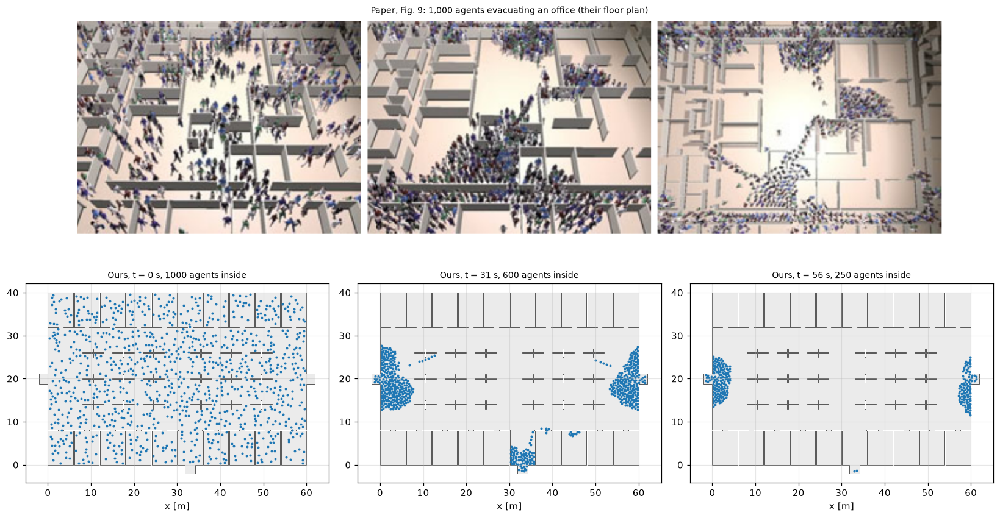

In [21]:

snap_rem = [1.0, 0.6, 0.25]
counts9 = df9.groupby("frame").size()
snap_frames = [counts9.index[np.argmax(counts9.to_numpy() <= q * s9["n_spawned"])] for q in snap_rem]
fig = plt.figure(figsize=(15, 8.5))
gs = fig.add_gridspec(2, 3, height_ratios=[0.75, 1.2])
ax_p = fig.add_subplot(gs[0, :])
show_img(ax_p, PAPER_FIG9_IMG, "Paper, Fig. 9: 1,000 agents evacuating an office (their floor plan)")
for k, fr in enumerate(snap_frames):
    ax = fig.add_subplot(gs[1, k])
    plot_polygon(walk9, ax=ax, add_points=False, facecolor="0.92", edgecolor="0.3", linewidth=0.6)
    g = df9[df9["frame"] == fr]
    ax.scatter(g["pos_x"], g["pos_y"], s=2.5, color="tab:blue")
    ax.set_aspect("equal")
    ax.set_title(f"Ours, t = {g['t'].iloc[0]:.0f} s, {len(g)} agents inside", fontsize=9)
    ax.set_xlabel("x [m]")
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig9_snapshots.png", dpi=130)
plt.show()


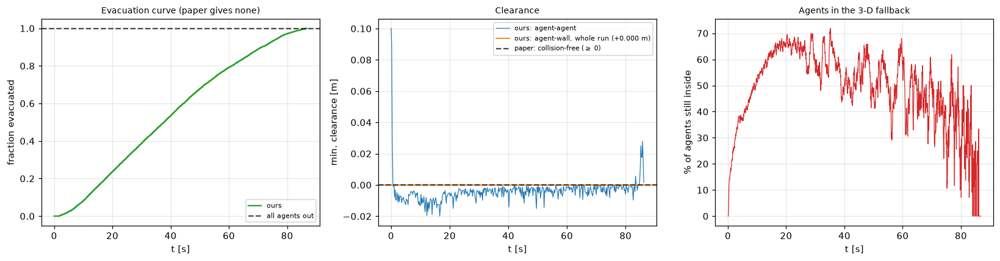

In [22]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax = axes[0]
ax.plot(t9, 1 - remaining9 / s9["n_spawned"], color="tab:green", label="ours")
ax.axhline(PAPER_ARRIVAL, lw=1.5, label="all agents out", **PAPER_STYLE)
ax.set_xlabel("t [s]"); ax.set_ylabel("fraction evacuated"); ax.legend(fontsize=7)
ax.set_title("Evacuation curve (paper gives none)", fontsize=9)
ax = axes[1]
ax.plot(c9["t"], c9["min_clearance"], lw=0.8, color="tab:blue", label="ours: agent-agent")
ax.axhline(wc9, color="tab:orange", lw=1.2, label=f"ours: agent-wall, whole run ({wc9:+.3f} m)")
ax.axhline(PAPER_MIN_CLEARANCE, lw=1.5, label="paper: collision-free ($\\geq$ 0)", **PAPER_STYLE)
ax.set_xlabel("t [s]"); ax.set_ylabel("min. clearance [m]"); ax.legend(fontsize=7)
ax.set_title("Clearance", fontsize=9)
ax = axes[2]
ax.plot(t9, 100 * frac3d9, lw=0.8, color="tab:red")
ax.set_xlabel("t [s]"); ax.set_ylabel("% of agents still inside")
ax.set_title("Agents in the 3-D fallback", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig9_metrics.png", dpi=130)
plt.show()


In [23]:

traj_9, area_9 = read_sqlite_file(str(RESULTS / "fig9_office_n1000.sqlite"))
n_frames = traj_9.data["frame"].nunique()
animate(traj_9, area_9, every_nth_frame=max(1, n_frames // 12), radius=AGENT_RADIUS,
        title_note="Fig. 9: office evacuation, 1,000 agents", width=900, height=650)



**Verdict: reproduced, as far as the paper lets us check.** The paper
reports no numbers for this scenario, so the comparison is necessarily
qualitative, and on a stand-in floor plan. All 1,000 agents leave the
building (the last after 86.8 s, half of them by 37.7 s), none gets stuck
behind a partition or in a room, and the run never crashes. The offices
and the hall empty within about 30 s. After that the evacuation is limited
by the exits: two large semicircular queues form at the side exits and
drain at a constant rate (the straight evacuation curve), like the crowds
piled up at openings in the paper's second and third snapshots.

**Walls:** the minimum agent–wall clearance over every recorded position
is 0.000 m. Agents slide along walls but never into them, as Section 5.4
promises (obstacle half-planes are hard and never relaxed).

**Agents:** from the first second on, the smallest clearance in each frame
hovers between about −1 and −2 cm (worst −2.0 cm). This is where the
paper's own caveat applies: in the queues 40–70 % of agents have an
infeasible 2-D linear program and use the 3-D fallback, which gives no
guarantee. Because this share looked high for a 0.4 agents/m² start, we
checked it. We re-solved 60 infeasible cases from the first 1.5 s with a
brute-force grid search: all 60 are genuinely infeasible, i.e. no bug in
the half-plane construction, but only marginally so (the least-penetrating
velocity violates the worst half-plane by just 1–22 mm/s). The cause is
the neighbour range: the paper's (v_A + v_B)·τ = 6 m puts 30–60 neighbours
in every agent's linear program at this density, and each adds a
half-plane through v_A + u/2. The authors' later RVO2 library caps the
list at the 10 nearest neighbours. We tried that cap on the first 5 s of
this scenario and it barely helps: 22 % of agent-steps in the fallback
instead of 27 %, though each step is 40 % cheaper. So the fallback is
mostly caused by the nearest neighbours, not the far ones. We kept the
paper's rule.



## 5. Running time vs. number of agents (Fig. 10b) and multi-core scaling (Fig. 10a)

**Paper's setup.** Circle and Office scenarios with N = 500 to 5,000 on
eight 2.66 GHz Xeon cores (OpenMP), reporting milliseconds per frame to
"solve the collision-avoidance linear program for every agent" (Circle) or
"update every agent" (Office): 8 ms and 15.6 ms at N = 5,000. Both scale
"approximately linearly with the number of agents".

**Our setup** (`run_timing_sweep.py`). The same N values, each point a
separate process, run one after another on an otherwise idle machine
(Apple M3 Pro). Each point times 40 steps from the start of the scenario,
dropping the first 5, at constant density: the Circle keeps 4 rows at
0.8 m spacing (so its radius grows with N), the office floor plan is
scaled by √(N/1000). We time the whole `sim.iterate()` and, separately,
the time spent inside our Python `compute_next_state` callbacks. JuPedSim
calls a Python model on **one core** (the callback holds the GIL), so
Fig. 10(a)'s multi-core speed-up cannot be measured here. To compare
like with like, we also convert the paper's 8-core times to an estimated
single-core time using the paper's own Fig. 10(a) speed-ups at 8 cores
(Office only; the paper gives no speed-up for the Circle).


In [24]:

ts = pd.DataFrame(json.load(open(RESULTS / "timing_sweep.json"))["rows"])
ts_table = ts.pivot(index="n", columns="scenario", values=["mean_step_time_ms", "mean_callback_time_ms"])
ts_table.round(1)


mean_step_time_ms         mean_callback_time_ms        
scenario            circle  office                circle  office
n                                                               
500                  102.7   180.5                  93.4   166.4
1000                 216.8   315.0                 202.6   287.0
2000                 495.7   628.8                 452.5   567.4
3000                 656.8   732.0                 617.5   679.1
4000                 756.5   999.0                 709.2   919.0
5000                 942.1  1140.8                 885.9  1041.6

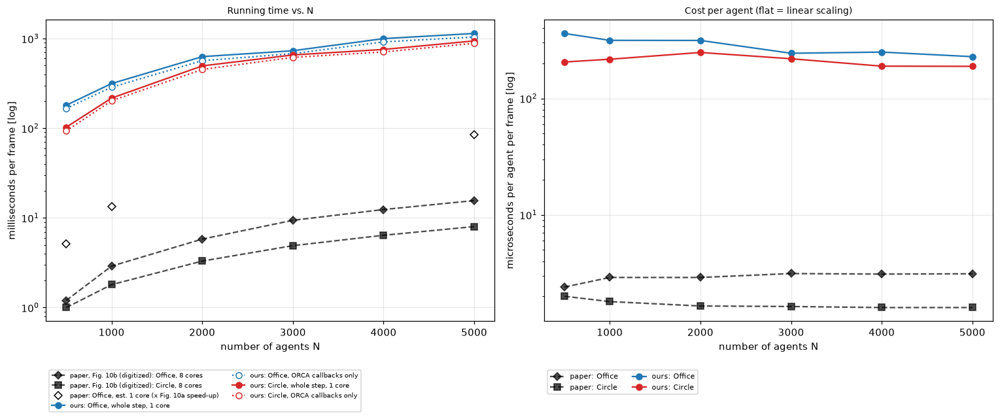

circle: linear fit R^2 ours 0.976 (paper 1.000); N=5000: ours 942 ms vs paper 8.0 ms on 8 cores -> ours is 118x slower
office: linear fit R^2 ours 0.982 (paper 0.999); N=5000: ours 1141 ms vs paper 15.6 ms on 8 cores -> ours is 73x slower
Office N=5000 vs the paper's estimated single-core time (84 ms): 14x slower


In [25]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
pn = np.array(PAPER_FIG10B["n"])
ax.plot(pn, PAPER_FIG10B["office_ms"], "D", label="paper, Fig. 10b (digitized): Office, 8 cores", **PAPER_STYLE)
ax.plot(pn, PAPER_FIG10B["circle_ms"], "s", label="paper, Fig. 10b (digitized): Circle, 8 cores", **PAPER_STYLE)
sp8 = {n: PAPER_FIG10A[n][-1] for n in (500, 1000, 5000)}
ax.plot(list(sp8), [PAPER_FIG10B["office_ms"][PAPER_FIG10B["n"].index(n)] * sp8[n] for n in sp8], "D",
        mfc="none", color="black", label="paper: Office, est. 1 core (x Fig. 10a speed-up)")
for scen, col in [("office", "tab:blue"), ("circle", "tab:red")]:
    g = ts[ts["scenario"] == scen].sort_values("n")
    ax.plot(g["n"], g["mean_step_time_ms"], "o-", color=col, label=f"ours: {scen.capitalize()}, whole step, 1 core")
    ax.plot(g["n"], g["mean_callback_time_ms"], "o:", mfc="white", color=col, label=f"ours: {scen.capitalize()}, ORCA callbacks only")
ax.set_yscale("log")
ax.set_xlabel("number of agents N"); ax.set_ylabel("milliseconds per frame [log]")
ax.set_title("Running time vs. N", fontsize=9)
ax.legend(fontsize=6.5, loc="upper left", bbox_to_anchor=(0.0, -0.15), ncol=2)

ax = axes[1]
ax.plot(pn, 1000 * np.array(PAPER_FIG10B["office_ms"]) / pn, "D", label="paper: Office", **PAPER_STYLE)
ax.plot(pn, 1000 * np.array(PAPER_FIG10B["circle_ms"]) / pn, "s", label="paper: Circle", **PAPER_STYLE)
for scen, col in [("office", "tab:blue"), ("circle", "tab:red")]:
    g = ts[ts["scenario"] == scen].sort_values("n")
    ax.plot(g["n"], 1000 * g["mean_step_time_ms"] / g["n"], "o-", color=col, label=f"ours: {scen.capitalize()}")
ax.set_yscale("log")
ax.set_xlabel("number of agents N"); ax.set_ylabel("microseconds per agent per frame [log]")
ax.set_title("Cost per agent (flat = linear scaling)", fontsize=9)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(0.0, -0.15), ncol=2)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig10_timing.png", dpi=130)
plt.show()

for scen in ["circle", "office"]:
    g = ts[ts["scenario"] == scen].sort_values("n")
    slope, icpt = np.polyfit(g["n"], g["mean_step_time_ms"], 1)
    pred = slope * g["n"] + icpt
    r2 = 1 - ((g["mean_step_time_ms"] - pred) ** 2).sum() / ((g["mean_step_time_ms"] - g["mean_step_time_ms"].mean()) ** 2).sum()
    paper = np.array(PAPER_FIG10B[f"{scen}_ms"])
    pslope, picpt = np.polyfit(pn, paper, 1)
    ppred = pslope * pn + picpt
    pr2 = 1 - ((paper - ppred) ** 2).sum() / ((paper - paper.mean()) ** 2).sum()
    t5000 = g.loc[g["n"] == 5000, "mean_step_time_ms"].iloc[0]
    print(f"{scen:>6}: linear fit R^2 ours {r2:.3f} (paper {pr2:.3f}); "
          f"N=5000: ours {t5000:.0f} ms vs paper {PAPER_TEXT_N5000_MS[scen]} ms on 8 cores "
          f"-> ours is {t5000 / PAPER_TEXT_N5000_MS[scen]:.0f}x slower")
t5000_off = ts[(ts.scenario == "office") & (ts.n == 5000)]["mean_step_time_ms"].iloc[0]
print(f"Office N=5000 vs the paper's estimated single-core time ({PAPER_TEXT_N5000_MS['office'] * sp8[5000]:.0f} ms): "
      f"{t5000_off / (PAPER_TEXT_N5000_MS['office'] * sp8[5000]):.0f}x slower")



**How representative is a 40-step window?** The windows above come from
the start of each scenario, before the crowd congests. The full
1,000-agent runs of Sections 3 and 4 show how the per-step cost changes
once the crowd congests (the paper does not say which phase its times
were averaged over). These two long runs were not timed on an idle
machine: they ran at the same time as each other and, later, as a few
short diagnostic runs, so read the curves below as indicative. The bumps
near t = 225 s and 250 s in the Circle curve are probably that
interference.


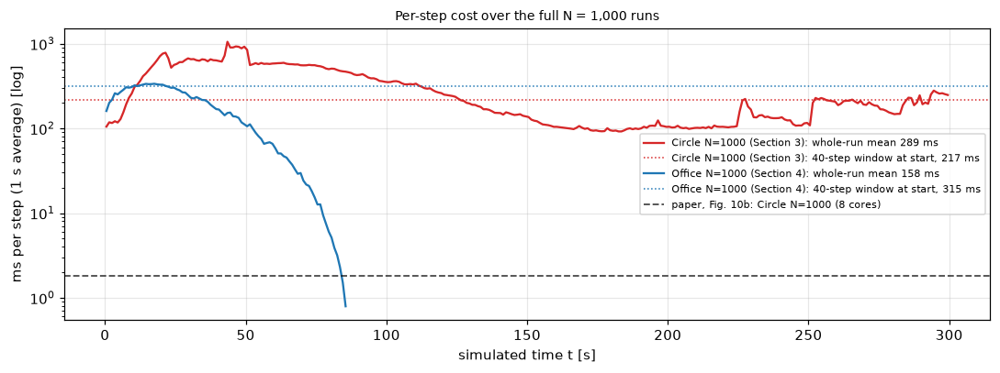

In [26]:

fig, ax = plt.subplots(figsize=(10, 3.8))
for s, lab, col in [(s8, "Circle N=1000 (Section 3)", "tab:red"), (s9, "Office N=1000 (Section 4)", "tab:blue")]:
    st = np.array(s["step_times_ms"])
    tt = (np.arange(len(st)) + 1) * s["dt"]
    k = max(1, int(1.0 / s["dt"]))
    ax.plot(tt[: len(st) // k * k].reshape(-1, k).mean(1), st[: len(st) // k * k].reshape(-1, k).mean(1),
            color=col, label=f"{lab}: whole-run mean {st.mean():.0f} ms")
    w = ts[(ts.scenario == ("circle" if s is s8 else "office")) & (ts.n == 1000)]["mean_step_time_ms"].iloc[0]
    ax.axhline(w, color=col, ls=":", lw=1, label=f"{lab}: 40-step window at start, {w:.0f} ms")
ax.axhline(PAPER_FIG10B["circle_ms"][1], lw=1.2, label="paper, Fig. 10b: Circle N=1000 (8 cores)", **PAPER_STYLE)
ax.set_yscale("log")
ax.set_xlabel("simulated time t [s]"); ax.set_ylabel("ms per step (1 s average) [log]")
ax.legend(fontsize=7)
ax.set_title("Per-step cost over the full N = 1,000 runs", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig10_cost_over_time.png", dpi=130)
plt.show()


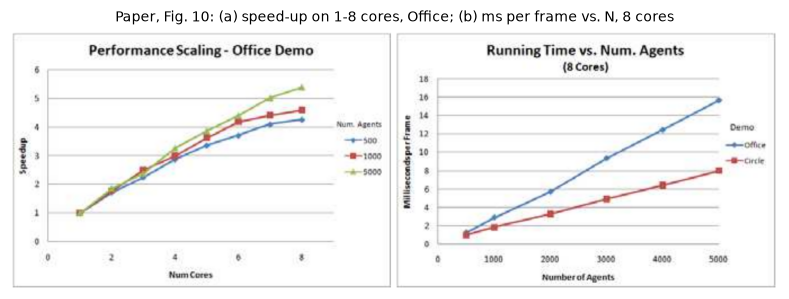

In [27]:

fig, ax = plt.subplots(figsize=(9, 3.2))
show_img(ax, PAPER_FIG10_IMG, "Paper, Fig. 10: (a) speed-up on 1-8 cores, Office; (b) ms per frame vs. N, 8 cores")
plt.show()



**Verdict: shape reproduced, absolute numbers not.**

- *Shape (Fig. 10b).* Both scenarios scale roughly linearly with N: a
  straight-line fit gives R² = 0.976 (Circle) and 0.982 (Office), against
  0.999–1.000 for the paper's digitized points. The cost per agent is flat
  (Circle, 190–250 µs) or falls slightly with N (Office, from 360 to
  230 µs), so nothing grows faster than linearly. The Office costs more per
  agent than the Circle, as in the paper.
- *Absolute time.* At N = 5,000 a step takes 0.94 s (Circle) and 1.14 s
  (Office): 118× and 73× slower than the paper's 8 cores. Even against the
  paper's own single-core estimate for the Office (15.6 ms × the 5.4
  speed-up of Fig. 10a ≈ 84 ms), we are 14× slower. The hardware does not
  explain this: an Apple M3 Pro core is faster than a 2007 Xeon core. What
  we measured instead: 91–94 % of each step is spent inside our Python
  `compute_next_state` callbacks (open vs. filled markers). JuPedSim's own
  work is the small rest. So the gap is the pure-Python per-agent
  callback, compared with the paper's C++. The paper's neighbour rule
  costs extra too: capping each agent at its 10 nearest neighbours, as
  RVO2 does, made the office's first 5 s 1.7× cheaper (165 vs. 286
  ms/step). That still leaves us more than an order of magnitude slower.
- *Phase matters.* In the full 1,000-agent Circle run the congested phase
  costs up to about 1 s per step, 4–5× the 40-step window at the start
  (217 ms). The sweep's windows are therefore optimistic for a whole run.
- *Multi-core scaling (Fig. 10a): not testable.* JuPedSim calls a
  Python operational model on one thread (the callback holds the GIL), so
  there is no parallel run to measure. The paper's curves are digitized in
  the reference cell for completeness only.



## 6. Summary

| # | Phenomenon (paper) | Reproduced? | Notes |
|---|---|---|---|
| 1 | Fig. 7a: two robots swap and "smoothly avoid" each other | ✅ | clearance +0.5 mm (collision-free), 0.25 m sideways bulge each, ≤ 15° per 0.1 s, 0.15 s delay; passes on the left where the paper passes on the right: an exact head-on tie decided by rounding/noise (3 of 5 seeds go left) |
| 2 | Fig. 7b: five robots "smoothly spiral" to antipodal points | ⚠️ | reproduced (same roundabout, same rotation sense, 5/5 arrive, no collision) only when the robots start already walking; the exactly symmetric setup deadlocks in 34 of 48 settings of τ / start speed / radius / noise, including 23 of 24 from rest; never collides |
| 3 | Fig. 8: 1,000 agents "smoothly move through the congestion" | ⚠️ | 998/1,000 reach their target (2 blocked by already-arrived agents, a side effect of our arrive-and-stop extension); overlaps ≤ 3.4 cm, deeper than 1 cm in 1 % of frames, only while 2-D LPs are infeasible (up to 92 % of agents); congestion forms as a symmetric packed disk rather than the paper's swirl and takes a median 143 s to clear (straight walk: 44 s; paper gives no times); reversals while walking ≥ 0.3 m/s: 76 agents |
| 4 | Fig. 9: 1,000 agents evacuate an office along planned paths | ✅ (qualitative; stand-in floor plan) | 100 % out in 86.8 s, no crash, agent–wall clearance never below 0 (hard obstacle constraints hold), agent–agent overlap ≤ 2.0 cm in the exit queues; 3-D fallback for ~50 % of agents per step, checked to be genuinely (if marginally) infeasible |
| 5 | Fig. 10b: running time grows ~linearly with N (Circle, Office) | ✅ shape / ❌ absolute | linear fits R² 0.98; flat per-agent cost; but 118× (Circle) and 73× (Office) slower than the paper's 8 cores at N = 5,000, 14× slower than its estimated single core; 91–94 % of the time is in the Python callback |
| 6 | Fig. 10a: near-linear speed-up on 1–8 cores | ❌ not testable | a Python operational model runs single-threaded under the GIL in JuPedSim |
| — | Guarantee: collision-free whenever the 2-D LP is feasible; walls never penetrated | ✅ | every sparse scenario ≥ 0 clearance (all 48 five-robot runs, the two-robot swap); walls: exactly 0 m minimum in the office; overlaps appear only where the paper itself drops the guarantee, and shrink with `dt` (−0.45 m at 0.2 s to −3 mm at 0.0125 s, N = 250) |

**Overall.** The half-plane construction, the linear programs and the
obstacle handling behave as the paper describes. Every guarantee the
paper states holds where the paper says it holds, and the dense-crowd
overlaps are small and discretization-limited. The paper's
pictures are reproduced in the easy cases (Fig. 7a, Fig. 9) and in shape
for the scaling (Fig. 10b). Where they are not, the reason is specific
and measured rather than a tuning issue. ORCA's behaviour in exactly
symmetric configurations (Fig. 7b, and the symmetric compression in
Fig. 8) depends on details the paper does not report, above all whether
agents start at rest. The absolute running times are dominated by the
pure-Python callback. The paper gives no numbers against which the
qualitative claims ("smoothly", the Fig. 9 evacuation) could be tested
more sharply, and there is no real-crowd data in it to validate against.
